In [ ]:
pip install arch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 11.2 MB/s eta 0:00:00


Importazione delle librerie principali necessarie per il progetto

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
from tensorflow.keras import Input
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import shap
from arch import arch_model
from scipy.stats import t as student_t

Definizione  dei parametri di base per l’analisi giornaliera su Bitcoin (ticker BTC-USD e intervallo temporale 2017-2024).

Download dei dati OHLCV giornalieri da Yahoo Finance utilizzando yfinance, ottenendo un DataFrame con indice temporale e colonne in formato MultiIndex.

Normalizzazione della struttura del DataFrame:
-appiattimento del MultiIndex delle colonne in nomi semplici (open, high, low, close, adj_close, volume);
-creazione una colonna esplicita 'date' a partire dall’indice;
-riordino delle colonne mettendo 'date' come prima colonna;
-reset dell’indice numerico.

Esecuzione di alcune verifiche di base:
-stampa delle prime righe del dataset normalizzato;
-mostra della lista delle colonne;
-indicazione del range temporale effettivo e il numero di osservazioni;
-controllo della presenza di eventuali valori mancanti per colonna.

In [ ]:
# IMPORTAZIONE E NORMALIZZAZIONE DATI GIORNALIERI BTC-USD


# Stile base per i grafici
plt.style.use("default")

#----------------------------------------
# Parametri per il download dei dati

TICKER = "BTC-USD"  # Bitcoin quotato in USD su Yahoo Finance

# Intervallo temporale daily
START_DATE = "2017-01-01"
END_DATE   = "2024-12-31"

#-----------------------------------------
# Download dei dati da Yahoo Finance

# Scarico la serie OHLCV (Open, High, Low, Close, Volume) con frequenza giornaliera.
# auto_adjust=False mantiene i prezzi OHLC originali così come forniti da Yahoo Finance.
df_daily_raw = yf.download(
    TICKER,
    start=START_DATE,
    end=END_DATE,
    interval="1d",
    auto_adjust=False
)

#Stampo informazioni diagnostiche sul dataframe
print("\ndf_daily_raw.head():")
print(df_daily_raw.head())

print("\ndf_daily_raw.info():")
print(df_daily_raw.info())

print("\ndf_daily_raw.columns (MultiIndex originale):")
print(df_daily_raw.columns)

#---------------------------------------------------------------
# Normalizzazione del DataFrame: da MultiIndex a colonne semplici

# Copia del dataframe grezzo
df_daily = df_daily_raw.copy()

# Appiattimento delle colonne MultiIndex:
# - Se la colonna è una tupla (es. ('Close', 'BTC-USD')), prendo solo il primo elemento ('Close')
# - Converto il nome in minuscolo e sostituisco eventuali spazi con underscore
df_daily.columns = [
    col[0].lower().replace(" ", "_") if isinstance(col, tuple)
    else str(col).lower().replace(" ", "_")
    for col in df_daily.columns
]

# Porto l'indice temporale nell'apposita colonna 'date'
df_daily["date"] = df_daily.index

# Riordino le colonne mettendo 'date' per prima, per leggibilità e per il resto della pipeline
cols = ["date"] + [c for c in df_daily.columns if c != "date"]
df_daily = df_daily[cols]

# Reset dell'indice numerico (0, 1, 2, ...) per avere un dataframe 'piatto'
df_daily = df_daily.reset_index(drop=True)

# Rinomina esplicita delle colonne chiave per chiarezza
rename_map = {
    "adj_close": "adj_close",
    "close": "close",
    "open": "open",
    "high": "high",
    "low": "low",
    "volume": "volume"
}

df_daily = df_daily.rename(columns=rename_map)

#------------------------------------------
# Verifiche di base sul dataset normalizzato


print("\ndf_daily.head() (dati normalizzati):")
print(df_daily.head())

print("\ndf_daily.columns (dopo normalizzazione):")
print(df_daily.columns)

print("\nRange date effettivo:")
print(df_daily["date"].min(), df_daily["date"].max())

print("\nNumero di osservazioni:", len(df_daily))

print("\nValori mancanti per colonna:")
print(df_daily.isna().sum())

[*********************100%***********************]  1 of 1 completed


df_daily_raw.head():
Price         Adj Close        Close         High          Low         Open  \
Ticker          BTC-USD      BTC-USD      BTC-USD      BTC-USD      BTC-USD   
Date                                                                          
2017-01-01   998.325012   998.325012  1003.080017   958.698975   963.658020   
2017-01-02  1021.750000  1021.750000  1031.390015   996.702026   998.617004   
2017-01-03  1043.839966  1043.839966  1044.079956  1021.599976  1021.599976   
2017-01-04  1154.729980  1154.729980  1159.420044  1044.400024  1044.400024   
2017-01-05  1013.380005  1013.380005  1191.099976   910.416992  1156.729980   

Price          Volume  
Ticker        BTC-USD  
Date                   
2017-01-01  147775008  
2017-01-02  222184992  
2017-01-03  185168000  
2017-01-04  344945984  
2017-01-05  510199008  

df_daily_raw.info():
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2921 entries, 2017-01-01 to 2024-12-30
Data columns (total 6 columns):
 #   Co

Ordinamento cronologico del dataset per garantire coerenza nelle analisi dinamiche.

Calcolo dei rendimenti logaritmici del prezzo di chiusura di Bitcoin e rimozione del primo valore non definito.

Esecuzione dei controlli preliminari:
-prime righe della nuova struttura;
-statistiche descrittive;
-assenza di NA;
-numero finale di osservazioni.

In [ ]:
# CALCOLO DEI RENDIMENTI LOGARITMICI DAILY BTC-USD

#----------------------------------------
# Assicurazione dell'ordinamento per data

# Anche se df_daily è già in ordine cronologico, lo ordino esplicitamente
# così da eliminare ogni possibile ambiguità nelle analisi successive.
df_daily = df_daily.sort_values("date").reset_index(drop=True)

#-----------------------------------
# Calcolo del rendimento logaritmico

# Formula utilizzata:
# r_t = ln(P_t) - ln(P_{t-1})
# dove P_t è il prezzo di chiusura.
df_daily["ret_log"] = np.log(df_daily["close"] / df_daily["close"].shift(1))

#---------------------------------------------------------
# Rimozione della prima osservazione (che ha ret_log = NaN)
df_daily = df_daily.dropna(subset=["ret_log"]).reset_index(drop=True)

#----------------------
# Verifiche preliminari

print("Prime righe con rendimenti logaritmici:")
print(df_daily[["date", "close", "ret_log"]].head())

print("\nStatistiche descrittive dei rendimenti logaritmici:")
print(df_daily["ret_log"].describe())

print("\nValori mancanti in ret_log:")
print(df_daily["ret_log"].isna().sum())

print("\nNumero totale di osservazioni dopo il calcolo dei rendimenti:")
print(len(df_daily))

Prime righe con rendimenti logaritmici:
        date        close   ret_log
0 2017-01-02  1021.750000  0.023193
1 2017-01-03  1043.839966  0.021389
2 2017-01-04  1154.729980  0.100960
3 2017-01-05  1013.380005 -0.130575
4 2017-01-06   902.200989 -0.116209

Statistiche descrittive dei rendimenti logaritmici:
count    2920.000000
mean        0.001552
std         0.037702
min        -0.464730
25%        -0.013883
50%         0.001356
75%         0.017828
max         0.225119
Name: ret_log, dtype: float64

Valori mancanti in ret_log:
0

Numero totale di osservazioni dopo il calcolo dei rendimenti:
2920


Grafici di:

-Serie temporale dei rendimenti logaritmici, per la visualizzazione dei periodi di alta/bassa volatilità;

-Distribuzione dei rendimenti (istogramma + KDE);

-ACF e PACF dei rendimenti, per valutare la presenza di autocorrelazione;

Inoltre stampa delle statistiche di forma (skewness, kurtosis)


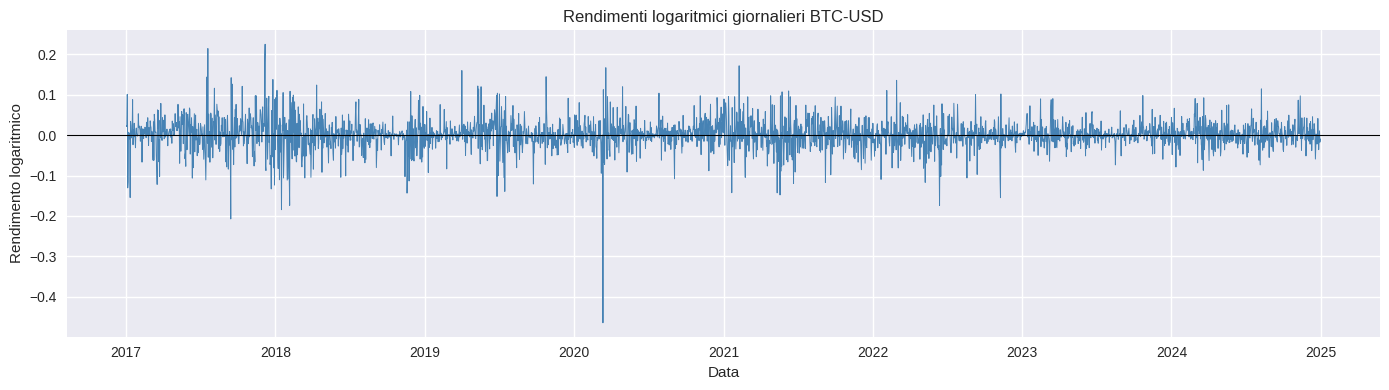

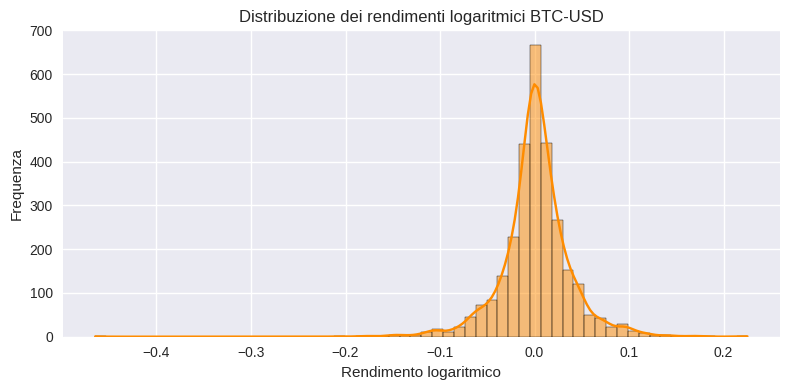

<Figure size 1000x400 with 0 Axes>

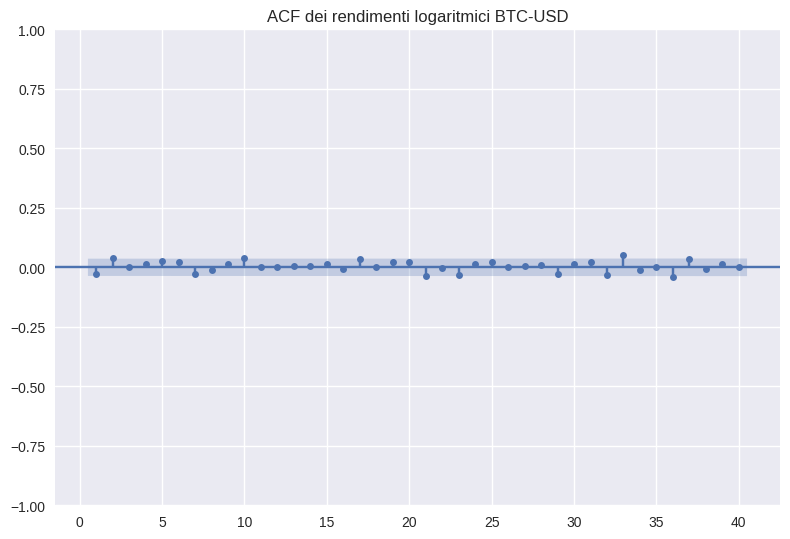

<Figure size 1000x400 with 0 Axes>

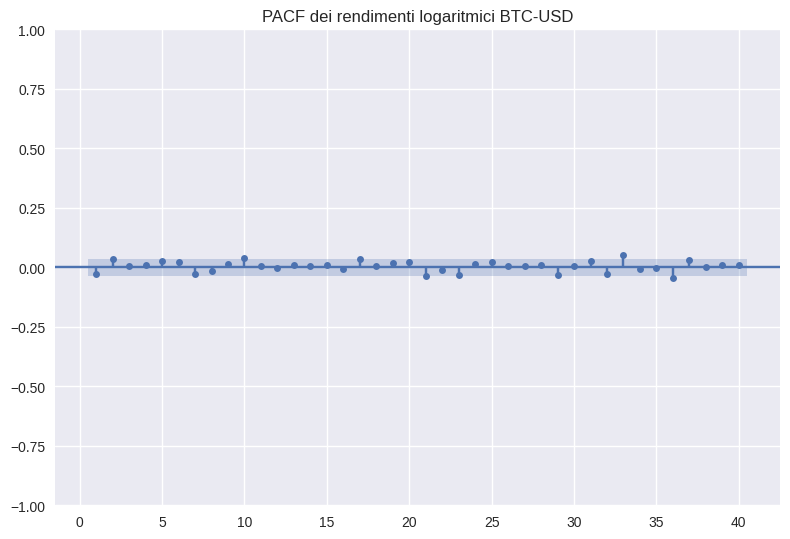

Skewness: -0.6670188511015962
Kurtosis: 11.348830817673655


In [ ]:
# EDA DEI RENDIMENTI LOGARITMICI


# Stile grafico
plt.style.use("seaborn-v0_8")


# Grafico della serie dei rendimenti logaritmici
plt.figure(figsize=(14, 4))
plt.plot(df_daily["date"], df_daily["ret_log"], color="steelblue", linewidth=0.7)
plt.axhline(0, color="black", linewidth=0.8)
plt.title("Rendimenti logaritmici giornalieri BTC-USD")
plt.xlabel("Data")
plt.ylabel("Rendimento logaritmico")
plt.tight_layout()
plt.show()


# Istogramma + Kernel Density Estimate
plt.figure(figsize=(8, 4))
sns.histplot(df_daily["ret_log"], bins=60, kde=True, color="darkorange")
plt.title("Distribuzione dei rendimenti logaritmici BTC-USD")
plt.xlabel("Rendimento logaritmico")
plt.ylabel("Frequenza")
plt.tight_layout()
plt.show()


# Funzione di autocorrelazione (ACF)
plt.figure(figsize=(10, 4))
plot_acf(df_daily["ret_log"], lags=40, zero=False)
plt.title("ACF dei rendimenti logaritmici BTC-USD")
plt.tight_layout()
plt.show()

# Funzione di autocorrelazione parziale (PACF)
plt.figure(figsize=(10, 4))
plot_pacf(df_daily["ret_log"], lags=40, zero=False, method="ywm")
plt.title("PACF dei rendimenti logaritmici BTC-USD")
plt.tight_layout()
plt.show()


# Ulteriori statistiche utili
skewness = df_daily["ret_log"].skew()
kurtosis = df_daily["ret_log"].kurtosis()

print("Skewness:", skewness)
print("Kurtosis:", kurtosis)

Definizione del rendimento logaritmico a t+1 (ret_log_tplus1), che rappresenta l’orizzonte di previsione della strategia.

Costruzione di un target di classificazione binaria y_class:

-1 → rendimento di domani positivo (segnale rialzista),

-0 → rendimento di domani non positivo (ribassista o nullo).

Costruzione di un target di regressione y_reg coerente con ret_log_tplus1, per stimare il valore del rendimento e non solo il verso.

Creazione di un primo set di feature di base: lag dei rendimenti logaritmici (ret_log_lag1, ret_log_lag2, ret_log_lag3, ret_log_lag5), che sintetizzano la dinamica recente della serie.

Rimozione delle righe con NaN dovuti a lag e shift, producendo un DataFrame pulito (df_daily_model) da cui estrarre:
-matrice delle feature X;
-target di classificazione y_class;
-target di regressione y_reg.

Stampa: -dimensione del dataset per i modelli;
-le prime righe delle feature + target;
-la distribuzione delle classi (per valutare eventuale sbilanciamento);
-la lista finale delle feature da utilizzare quando verrannò aggiunti i componenti ARIMA/ARFIMA.

In [ ]:
# DEFINIZIONE DEL TARGET E DELLE FEATURE BASE

#--------------------------------------------------
# Creazione del rendimento logaritmico futuro (t+1)
# Definiscoo una nuova colonna con il rendimento a t+1.
df_daily["ret_log_tplus1"] = df_daily["ret_log"].shift(-1)

#--------------------------------------------------------------------
# Definizione del target di classificazione (direzione del rendimento)

# Target binario:
# y = 1 se il rendimento logaritmico del giorno successivo è > 0 (movimento rialzista)
# y = 0 altrimenti (movimento ribassista o nullo)
df_daily["y_class"] = (df_daily["ret_log_tplus1"] > 0).astype(int)

# Target di regressione: prevedere direttamente il valore del rendimento logaritmico a t+1
# Questo può essere usato in parallelo, ma per ora la pipeline principale è di classificazione.
df_daily["y_reg"] = df_daily["ret_log_tplus1"]

#-------------------------------------------------------
# Creazione della feature lag dei rendimenti logaritmici

# Le lag dei rendimenti contengono informazione sulla dinamica recente del mercato,
# con un set compatto di lag ad 1, 2, 3, 5 giorni.
lag_list = [1, 2, 3, 5]

for lag in lag_list:
    col_name = f"ret_log_lag{lag}"
    df_daily[col_name] = df_daily["ret_log"].shift(lag)

#-------------------------------------------------
# Rimozione delle osservazioni con valori mancanti

# Le prime osservazioni avranno NaN a causa delle lag e dello shift a t+1.
# Per evitare problemi nei modelli, rimuovo tutte le righe con NaN nelle
# colonne fondamentali target (y_class, y_reg) e lag dei rendimenti.
cols_required = ["ret_log_tplus1", "y_class", "y_reg"] + [f"ret_log_lag{lag}" for lag in lag_list]

df_daily_model = df_daily.dropna(subset=cols_required).reset_index(drop=True)

#--------------------------------------------------
# Costruzione esplicita di X (feature) e y (target)

feature_cols = [f"ret_log_lag{lag}" for lag in lag_list]

X = df_daily_model[feature_cols].copy()     # matrice delle feature di base
y_class = df_daily_model["y_class"].copy() # target di classificazione
y_reg = df_daily_model["y_reg"].copy()     # target di regressione (eventuale)

#---------------------------------------------------------
# Verifiche rapide sulla struttura dei dati per il modello

print("Dimensione di df_daily_model:", df_daily_model.shape)
print("\nPrime righe di df_daily_model (feature + target):")
print(df_daily_model[["date"] + feature_cols + ["y_class", "y_reg"]].head())

print("\nDistribuzione della classe (y_class):")
print(y_class.value_counts(normalize=True).rename("freq_relativa"))

print("\nLista delle feature utilizzate:")
print(feature_cols)


Dimensione di df_daily_model: (2914, 15)

Prime righe di df_daily_model (feature + target):
        date  ret_log_lag1  ret_log_lag2  ret_log_lag3  ret_log_lag5  y_class  \
0 2017-01-07     -0.116209     -0.130575      0.100960      0.023193        1   
1 2017-01-08      0.007051     -0.116209     -0.130575      0.021389        0   
2 2017-01-09      0.002873      0.007051     -0.116209      0.100960        1   
3 2017-01-10     -0.009229      0.002873      0.007051     -0.130575        0   
4 2017-01-11      0.005359     -0.009229      0.002873     -0.116209        1   

      y_reg  
0  0.002873  
1 -0.009229  
2  0.005359  
3 -0.154477  
4  0.034222  

Distribuzione della classe (y_class):
y_class
1    0.525395
0    0.474605
Name: freq_relativa, dtype: float64

Lista delle feature utilizzate:
['ret_log_lag1', 'ret_log_lag2', 'ret_log_lag3', 'ret_log_lag5']


Implementazione della componente lineare ARIMA per il modello ibrido:

-Walk-forward expanding window utilizzando una finestra iniziale di circa un anno (INITIAL_TRAIN_SIZE = 365) e il modello ARIMA viene ricalibrato ogni 30 osservazioni (REFIT_EVERY = 30);

-Impego di ARIMA(1,0,1) sulla serie dei rendimenti logaritmici. Per ogni data t si ottiene una previsione a un passo avanti r^t+1 (ARIMA);

-Per ciascuna riga del dataset (osservazione al tempo t), la feature arima_pred_tplus1 rappresenta la previsione ARIMA del rendimento del giorno successivo;

-Si combina il set di lag dei rendimenti logaritmici con la previsione ARIMA e
si ottiene così un dataset df_daily_hybrid_arima pronto per l’addestramento dell’ensemble ML, in cui la componente lineare catturata dall’ARIMA viene fornita al modello come informazione aggiuntiva;

In [ ]:
# COMPONENTE ARIMA COME FEATURE IBRIDA

#---------------------------------
# Parametri del walk-forward ARIMA
INITIAL_TRAIN_SIZE = 365   # ~1 anno di dati per il primo fit
REFIT_EVERY = 30           # ricalibrazione ogni ~30 giorni

df_daily_model_arima = df_daily_model.copy()

# Colonna che conterrà la previsione ARIMA del rendimento a t+1
df_daily_model_arima["arima_pred_tplus1"] = np.nan

#----------------------------------------------------------
# Loop walk-forward per stima ARIMA(1,0,1) e forecast a t+1

current_model = None

for i in range(INITIAL_TRAIN_SIZE, len(df_daily_model_arima) - 1):
    # Ogni REFIT_EVERY osservazioni, ricalibra il modello ARIMA con finestra espandente
    if (i - INITIAL_TRAIN_SIZE) % REFIT_EVERY == 0 or current_model is None:
        train_series = df_daily_model_arima["ret_log"].iloc[: i + 1]

        current_model = ARIMA(train_series, order=(1, 0, 1)).fit()

    # Forecast 1-step-ahead: previsione di r_{i+1}
    forecast = current_model.forecast(steps=1)

    # Prendo il primo elemento in modo posizionale (.iloc[0])
    pred_value = float(forecast.iloc[0])

    # Allineo la previsione al tempo i, riga i → feature calcolata al tempo t
    df_daily_model_arima.loc[i, "arima_pred_tplus1"] = pred_value

#-----------------------------------------------------------
# Ricostruzione del dataset per il modello ibrido ARIMA + ML

feature_cols_base = feature_cols.copy()  # ['ret_log_lag1', 'ret_log_lag2', 'ret_log_lag3', 'ret_log_lag5']
feature_cols_hybrid_arima = feature_cols_base + ["arima_pred_tplus1"]

cols_required_hybrid = feature_cols_hybrid_arima + ["y_class", "y_reg"]

df_daily_hybrid_arima = (
    df_daily_model_arima
    .dropna(subset=cols_required_hybrid)
    .reset_index(drop=True)
)

X_hybrid_arima = df_daily_hybrid_arima[feature_cols_hybrid_arima].copy()
y_class_hybrid = df_daily_hybrid_arima["y_class"].copy()
y_reg_hybrid = df_daily_hybrid_arima["y_reg"].copy()

#--------------------------------------------------------
# Verifiche sulla struttura del dataset ibrido ARIMA + ML

print("Dimensione di df_daily_hybrid_arima:", df_daily_hybrid_arima.shape)

print("\nPrime righe del dataset ibrido (feature + target):")
print(df_daily_hybrid_arima[["date"] + feature_cols_hybrid_arima + ["y_class", "y_reg"]].head())

print("\nStatistiche sintetiche di arima_pred_tplus1:")
print(df_daily_hybrid_arima["arima_pred_tplus1"].describe())

print("\nDistribuzione della classe (y_class) nel dataset ibrido:")
print(y_class_hybrid.value_counts(normalize=True).rename("freq_relativa"))

print("\nLista delle feature ibride ARIMA + ML:")
print(feature_cols_hybrid_arima)


Dimensione di df_daily_hybrid_arima: (2548, 16)

Prime righe del dataset ibrido (feature + target):
        date  ret_log_lag1  ret_log_lag2  ret_log_lag3  ret_log_lag5  \
0 2018-01-07      0.005578      0.110945      0.025858      0.092589   
1 2018-01-08     -0.061741      0.005578      0.110945      0.014505   
2 2018-01-09     -0.082675     -0.061741      0.005578      0.025858   
3 2018-01-10     -0.038620     -0.082675     -0.061741      0.110945   
4 2018-01-11      0.025562     -0.038620     -0.082675      0.005578   

   arima_pred_tplus1  y_class     y_reg  
0           0.006629        0 -0.082675  
1           0.006629        0 -0.038620  
2           0.006629        1  0.025562  
3           0.006629        0 -0.110581  
4           0.006629        1  0.041983  

Statistiche sintetiche di arima_pred_tplus1:
count    2548.000000
mean        0.002226
std         0.002126
min        -0.003034
25%         0.001127
50%         0.001661
75%         0.003008
max         0.010935
N

Implementazione della differenziazione frazionaria dei rendimenti logaritmici, con ordine d=0.4, per modellare esplicitamente la long memory della serie, seguendo l’approccio ARFIMA (AutoRegressive Fractionally Integrated Moving Average):

-Stima di un ARMA(1,1) sulla serie frazionariamente differenziata, ottenendo una previsione 1-step-ahead: r^(t+1)(fd) utilizzata come proxy della componente ARFIMA;

-Utilizzo di un walk-forward expanding window con ricalibrazione periodica (ogni 30 osservazioni), analogamente a quanto fatto per la componente ARIMA, per riflettere l’evoluzione dinamica delle condizioni di mercato;

-Costruzione del dataset ibrido completo df_daily_hybrid_full, che contiene:
lag dei rendimenti (ret_log_lag1, ret_log_lag2, …), previsione ARIMA arima_pred_tplus1, previsione ARFIMA-like arfima_pred_tplus1, target y_class e y_reg.

Questo dataset sarà la base per l’ensemble di modelli di machine learning (Logistic Regression, Random Forest, XGBoost), che potrà apprendere relazioni non lineari e interazioni non colte dai soli componenti ARIMA/ARFIMA.

In [ ]:
warnings.filterwarnings("ignore", category=ConvergenceWarning)

# COMPONENTE ARFIMA COME FEATURE IBRIDA

#--------------------------------------------------------------------
# Funzione per la differenziazione frazionaria (Lopez de Prado)

def fracdiff(series, d, thresh=1e-4):
    """
    Applica la differenziazione frazionaria a una serie univariata.

    Parametri:
    series : pd.Series
        Serie temporale da differenziare.
    d : float
        Ordine di differenziazione frazionaria (0 < d < 1).
    thresh : float
        Soglia di arresto per i pesi (quando sono molto piccoli).

    Ritorna:
    pd.Series
        Serie frazionariamente differenziata, con alcuni valori iniziali NaN.
    """
    # Mi assicuro di lavorare su una Series pandas
    s = series.astype(float).copy()

    # Calcolo dei pesi della differenziazione frazionaria
    w = [1.0]
    k = 1
    while True:
        w_k = -w[-1] * (d - k + 1) / k
        if abs(w_k) < thresh:
            break
        w.append(w_k)
        k += 1

    w = np.array(w[::-1])  # invertiamo l'ordine per la convoluzione
    width = len(w)

    # Applicazione dei pesi tramite dot product "scorrevole"
    out = np.full_like(s.values, np.nan, dtype=float)

    for i in range(width - 1, len(s)):
        window = s.values[i - width + 1 : i + 1]
        out[i] = np.dot(w, window)

    return pd.Series(out, index=s.index, name=f"fd_d{d}")

#----------------------------------------------------------------------------
# Preparazione del dataframe per ARFIMA-like (fractional differencing + ARMA)


# Parto dal dataframe che già contiene la componente ARIMA
df_daily_model_arfima = df_daily_model_arima.copy()

# Mi assicuro che 'date' sia di tipo datetime
df_daily_model_arfima["date"] = pd.to_datetime(df_daily_model_arfima["date"])

#----------------------------------------------------------------------------
# Parametro di differenziazione frazionaria
D_FRAC = 0.4

# Applico la differenziazione frazionaria sui rendimenti logaritmici
df_daily_model_arfima["ret_log_fd"] = fracdiff(df_daily_model_arfima["ret_log"], d=D_FRAC)

print("Verifica ret_log_fd (fractional differencing):")
print(df_daily_model_arfima[["date", "ret_log", "ret_log_fd"]].head(10))

# Inizializzo la colonna che conterrà la previsione ARFIMA-like del rendimento a t+1
df_daily_model_arfima["arfima_pred_tplus1"] = np.nan

#----------------------------------------------------------
# Loop walk-forward su serie frazionariamente differenziata

INITIAL_TRAIN_SIZE_ARFIMA = INITIAL_TRAIN_SIZE   # uso lo stesso criterio di ARIMA
REFIT_EVERY_ARFIMA = REFIT_EVERY                 # stessa frequenza di ricalibrazione

current_model_arfima = None

# Individuo il primo indice in cui ret_log_fd non è NaN
first_valid_fd_idx = df_daily_model_arfima["ret_log_fd"].first_valid_index()
if first_valid_fd_idx is None:
    raise ValueError("La serie frazionariamente differenziata ret_log_fd è completamente NaN.")

# Converto in posizione intera (nel RangeIndex)
first_valid_fd_pos = int(first_valid_fd_idx)

# Parto dall'indice massimo tra:
# - la dimensione minima per il training,
# - il primo punto valido della serie frazionariamente differenziata
start_idx = max(INITIAL_TRAIN_SIZE_ARFIMA, first_valid_fd_pos + 1)

for i in range(start_idx, len(df_daily_model_arfima) - 1):
    # Ogni REFIT_EVERY_ARFIMA osservazioni, ricalibra il modello ARMA(1,1)
    # sulla serie frazionariamente differenziata.
    if (i - start_idx) % REFIT_EVERY_ARFIMA == 0 or current_model_arfima is None:
        # 1) Ritaglio il dataframe fino all'indice corrente
        df_train_slice = df_daily_model_arfima.iloc[first_valid_fd_pos : i + 1].copy()

        # 2) Tengo solo le righe con ret_log_fd non NaN
        df_train_slice = df_train_slice.dropna(subset=["ret_log_fd"])

        # 3) Costruisco la serie con indice = 'date' e frequenza giornaliera
        train_series_fd = (
            df_train_slice
            .set_index("date")["ret_log_fd"]
            .asfreq("D")   # assegna frequenza 'D' per compatibilità con statsmodels
        )

        # 4) ARMA(1,1) implementato come ARIMA(1,0,1) sulla serie fd con DatetimeIndex
        current_model_arfima = ARIMA(train_series_fd, order=(1, 0, 1)).fit()

    # Forecast 1-step-ahead sulla serie frazionariamente differenziata
    forecast_fd = current_model_arfima.forecast(steps=1)
    pred_fd_value = float(forecast_fd.iloc[0])

    # Allineo la previsione al tempo i
    df_daily_model_arfima.loc[i, "arfima_pred_tplus1"] = pred_fd_value

#------------------------------------------------------------
# Costruzione del dataset ibrido completo ARIMA + ARFIMA + ML

feature_cols_base = feature_cols.copy()  # ['ret_log_lag1', 'ret_log_lag2', 'ret_log_lag3', 'ret_log_lag5']
feature_cols_hybrid_full = feature_cols_base + ["arima_pred_tplus1", "arfima_pred_tplus1"]

cols_required_hybrid_full = feature_cols_hybrid_full + ["y_class", "y_reg"]

df_daily_hybrid_full = (
    df_daily_model_arfima
    .dropna(subset=cols_required_hybrid_full)
    .reset_index(drop=True)
)

X_hybrid_full = df_daily_hybrid_full[feature_cols_hybrid_full].copy()
y_class_hybrid_full = df_daily_hybrid_full["y_class"].copy()
y_reg_hybrid_full = df_daily_hybrid_full["y_reg"].copy()

#------------------------------------------------------
# Verifiche sulla struttura del dataset ibrido completo

print("\nDimensione di df_daily_hybrid_full:", df_daily_hybrid_full.shape)

print("\nPrime righe del dataset ibrido completo (feature + target):")
print(df_daily_hybrid_full[["date"] + feature_cols_hybrid_full + ["y_class", "y_reg"]].head())

print("\nStatistiche sintetiche di arfima_pred_tplus1:")
print(df_daily_hybrid_full["arfima_pred_tplus1"].describe())

print("\nDistribuzione della classe (y_class) nel dataset ibrido completo:")
print(y_class_hybrid_full.value_counts(normalize=True).rename("freq_relativa"))

print("\nLista finale delle feature ibride ARIMA/ARFIMA + ML:")
print(feature_cols_hybrid_full)


Verifica ret_log_fd (fractional differencing):
        date   ret_log  ret_log_fd
0 2017-01-07  0.007051         NaN
1 2017-01-08  0.002873         NaN
2 2017-01-09 -0.009229         NaN
3 2017-01-10  0.005359         NaN
4 2017-01-11 -0.154477         NaN
5 2017-01-12  0.034222         NaN
6 2017-01-13  0.023515         NaN
7 2017-01-14 -0.006785         NaN
8 2017-01-15  0.004129         NaN
9 2017-01-16  0.011778         NaN

Dimensione di df_daily_hybrid_full: (2548, 18)

Prime righe del dataset ibrido completo (feature + target):
        date  ret_log_lag1  ret_log_lag2  ret_log_lag3  ret_log_lag5  \
0 2018-01-07      0.005578      0.110945      0.025858      0.092589   
1 2018-01-08     -0.061741      0.005578      0.110945      0.014505   
2 2018-01-09     -0.082675     -0.061741      0.005578      0.025858   
3 2018-01-10     -0.038620     -0.082675     -0.061741      0.110945   
4 2018-01-11      0.025562     -0.038620     -0.082675      0.005578   

   arima_pred_tplus1  arfi

Costruzione di un ensemble di tre modelli di classificazione:
-Regressione logistica (modello lineare);
-Random Forest (modello non lineare ad alberi);
-XGBoost (metodo di gradient boosting su alberi)

Feature del modello:
-lag dei rendimenti logaritmici;
-previsione ARIMA del rendimento logaritmico a t+1;
-previsione ARFIMA-like (fractional differencing + ARMA) del rendimento logaritmico a t+1.

Implementazione di un walk-forward expanding window. Si parte da una finestra iniziale di 365 osservazioni per stimare l’ensemble, poi i modelli vengono ricalibrati ogni 30 giorni circa e a ogni passo viene prodotta una previsione out-of-sample per il giorno successivo.

Combinazione  delle probabilità prodotte dai tre modelli tramite soft voting, ottenendo una probabilità ensemble di rialzo (ens_proba) e una classe predetta (ens_pred).

Calcolo di:
-accuratezza complessiva dell’ensemble;
-ROC-AUC;
-matrice di confusione;
-report di classificazione;

Memorizzazione dei risultati nel DataFrame df_ml, che contiene per ogni giorno:
-feature ibride ARIMA/ARFIMA;
-target reale (y_class);
-predizione dell’ensemble (ens_pred) e probabilità associata (ens_proba).

In [ ]:
# ENSEMBLE DI MODELLI ML SU FEATURE ARIMA/ARFIMA

#------------------------------------------
# Preparazione del dataset per il ML ibrido

df_ml = df_daily_hybrid_full.copy()

feature_cols_hybrid_full = [
    "ret_log_lag1",
    "ret_log_lag2",
    "ret_log_lag3",
    "ret_log_lag5",
    "arima_pred_tplus1",
    "arfima_pred_tplus1",
]

X_full = df_ml[feature_cols_hybrid_full].copy()
y_full = df_ml["y_class"].copy()

# Inizializzo le colonne per salvare le previsioni out-of-sample dell'ensemble
df_ml["ens_proba"] = np.nan   # probabilità stimata di classe 1 (rialzo)
df_ml["ens_pred"] = np.nan    # classe predetta (0/1)

#-------------------------------------
# Parametri del walk-forward per il ML

INITIAL_TRAIN_SIZE_ML = 365   # numero minimo di osservazioni per il primo training
REFIT_EVERY_ML = 30           # ricalibrazione dei modelli ogni 30 osservazioni

# Liste per salvare gli output del backtest ML
y_true_list = []
y_pred_list = []
y_proba_list = []
date_list   = []

# Modelli inizialmente non definiti
lr_model = None
rf_model = None
xgb_model = None

#-----------------------------------------------------------
# Loop walk-forward: training dinamico + ensemble prediction

for i in range(INITIAL_TRAIN_SIZE_ML, len(df_ml)):
    # Indici di training: tutte le osservazioni fino a i-1 (finestra espandente)
    X_train = X_full.iloc[:i]
    y_train = y_full.iloc[:i]

    # Osservazione di test (out-of-sample) al tempo i
    X_test = X_full.iloc[i:i+1]
    y_test = y_full.iloc[i]
    date_i = df_ml.loc[i, "date"]

    # Ricalibrazione dei modelli ogni REFIT_EVERY_ML osservazioni
    if (i - INITIAL_TRAIN_SIZE_ML) % REFIT_EVERY_ML == 0 or lr_model is None:

        # Logistic Regression
        lr_model = LogisticRegression(
            max_iter=1000,
            solver="lbfgs"
        )
        lr_model.fit(X_train, y_train)

        # Random Forest
        rf_model = RandomForestClassifier(
            n_estimators=300,
            max_depth=None,
            min_samples_split=5,
            min_samples_leaf=2,
            random_state=42,
            n_jobs=-1
        )
        rf_model.fit(X_train, y_train)

        # XGBoost
        xgb_model = XGBClassifier(
            n_estimators=300,
            max_depth=3,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            eval_metric="logloss",
            n_jobs=-1
        )
        xgb_model.fit(X_train, y_train)

    #--------------------------------------------------------------
    # Previsione delle probabilità per la classe 1 (rendimento > 0)

    proba_lr  = lr_model.predict_proba(X_test)[:, 1][0]
    proba_rf  = rf_model.predict_proba(X_test)[:, 1][0]
    proba_xgb = xgb_model.predict_proba(X_test)[:, 1][0]

    # Ensemble soft-voting: media delle probabilità dei tre modelli
    proba_ens = (proba_lr + proba_rf + proba_xgb) / 3.0

    # Classe predetta dall'ensemble (soglia 0.5)
    pred_ens = int(proba_ens >= 0.5)


    # Salvataggio dei risultati

    df_ml.loc[i, "ens_proba"] = proba_ens
    df_ml.loc[i, "ens_pred"] = pred_ens

    y_true_list.append(y_test)
    y_pred_list.append(pred_ens)
    y_proba_list.append(proba_ens)
    date_list.append(date_i)

#--------------------------------------------------------------
# Conversione dei risultati in array e calcolo metriche globali

y_true_arr  = np.array(y_true_list)
y_pred_arr  = np.array(y_pred_list)
y_proba_arr = np.array(y_proba_list)

# Accuratezza complessiva del classificatore ensemble
accuracy = accuracy_score(y_true_arr, y_pred_arr)

# ROC-AUC (capacità discriminativa in termini di ranking)
roc_auc = roc_auc_score(y_true_arr, y_proba_arr)

cm = confusion_matrix(y_true_arr, y_pred_arr)

print("Numero di previsioni out-of-sample valutate:", len(y_true_arr))
print("\nAccuratezza complessiva ensemble:", round(accuracy, 4))
print("\nROC-AUC ensemble:", round(roc_auc, 4))
print("\nMatrice di confusione:")
print(cm)

print("\nReport di classificazione:")
print(classification_report(y_true_arr, y_pred_arr, digits=4))

# ------------------------------------------------------------
# Verifica finale: prime righe con predizioni ensemble

print("\nPrime righe del dataframe con colonna ens_pred / ens_proba:")
print(df_ml[["date"] + feature_cols_hybrid_full + ["y_class", "ens_pred", "ens_proba"]].head(10))

Numero di previsioni out-of-sample valutate: 2183

Accuratezza complessiva ensemble: 0.4796

ROC-AUC ensemble: 0.4807

Matrice di confusione:
[[411 650]
 [486 636]]

Report di classificazione:
              precision    recall  f1-score   support

           0     0.4582    0.3874    0.4198      1061
           1     0.4946    0.5668    0.5282      1122

    accuracy                         0.4796      2183
   macro avg     0.4764    0.4771    0.4740      2183
weighted avg     0.4769    0.4796    0.4755      2183


Prime righe del dataframe con colonna ens_pred / ens_proba:
        date  ret_log_lag1  ret_log_lag2  ret_log_lag3  ret_log_lag5  \
0 2018-01-07      0.005578      0.110945      0.025858      0.092589   
1 2018-01-08     -0.061741      0.005578      0.110945      0.014505   
2 2018-01-09     -0.082675     -0.061741      0.005578      0.025858   
3 2018-01-10     -0.038620     -0.082675     -0.061741      0.110945   
4 2018-01-11      0.025562     -0.038620     -0.082675     

Ricostruzione del dataset per il modello ibrido ARIMA + LSTM, utilizzando come feature i lag dei rendimenti logaritmicie e la previsione ARIMA del rendimento a t+1.

Conversione del dataset in sequenze temporali di 20 giorni per l’input dell’LSTM, dove ogni campione rappresenta l’evoluzione recente delle feature e il target è la direzione del rendimento del giorno successivo.

Implementazione di una walk-forward expanding window in cui il modello viene addestrato inizialmente su 365 sequenze, poi viene ricalibrato ogni 30 previsioni e a ogni passo produce una previsione out-of-sample.

Applicazione della standardizzazione delle feature a ogni ricalibrazione per stabilizzare l’addestramento della rete.

Definizione e addestramento di un modello LSTM costruito da:
-uno strato LSTM (32 unità);
-dropout per ridurre l’overfitting;
-un’uscita sigmoide che restituisce la probabilità di rialzo.

Per ogni giorno fuori campione:
-stima della probabilità di classe 1 (proba_1);
-produzione della classe predetta (y_pred);
-registro della previsione con la data corrispondente.

Al termine, calcolo di:
-accuratezza;
-ROC-AUC;
-matrice di confusione;
-report di classificazione,

Inoltre creazione di un DataFrame con tutte le previsioni out-of-sample (results_lstm_arima).

In [ ]:
# MODELLO IBRIDO ARIMA + LSTM

#-------------------------------------------
# Ricostruzione del dataset per ARIMA + LSTM

df_ml_lstm_arima = df_daily_hybrid_full.copy()

# Feature usate per ARIMA + LSTM: lag dei rendimenti + previsione ARIMA
feature_cols_lstm_arima = [
    "ret_log_lag1",
    "ret_log_lag2",
    "ret_log_lag3",
    "ret_log_lag5",
    "arima_pred_tplus1",
]

X_full = df_ml_lstm_arima[feature_cols_lstm_arima].copy().values
y_full = df_ml_lstm_arima["y_class"].astype(int).values
dates_full = df_ml_lstm_arima["date"].values

print("Dimensione dataset base per LSTM (righe, features):", X_full.shape)

#----------------------------------------------
# Costruzione delle sequenze temporali per LSTM

# Lunghezza della finestra temporale (numero di giorni usati come input)
window_len = 20

X_seq_list = []
y_seq_list = []
dates_seq_list = []

n_rows = X_full.shape[0]

# Per ogni indice idx >= window_len, costruisco
# - input: sequenza di lunghezza 'window_len' con feature da idx-window_len a idx-1
# - target: y_full[idx] → direzione del rendimento del giorno successivo associata alla riga idx
for idx in range(window_len, n_rows):
    seq_X = X_full[idx - window_len : idx, :]  # shape: (window_len, n_features)
    target_y = y_full[idx]                   # etichetta del "giorno idx"
    date_ref = dates_full[idx]               # data associata alla decisione

    X_seq_list.append(seq_X)
    y_seq_list.append(target_y)
    dates_seq_list.append(date_ref)

X_seq = np.array(X_seq_list)          # shape: (n_samples, window_len, n_features)
y_seq = np.array(y_seq_list)          # shape: (n_samples,)
dates_seq = np.array(dates_seq_list)  # shape: (n_samples,)

n_samples, _, n_features = X_seq.shape

print("\nForma di X_seq (campioni, timesteps, features):", X_seq.shape)
print("\nLunghezza y_seq:", y_seq.shape[0])

#------------------------------------
# Parametri del walk-forward per LSTM

INITIAL_TRAIN_SIZE_LSTM = 365   # numero minimo di campioni-sequenza per il primo training
REFIT_EVERY_LSTM = 30           # ricalibrazione del modello ogni 30 previsioni

# Liste per salvare i risultati out-of-sample
y_true_list = []
y_pred_list = []
y_proba_list = []
date_oos_list = []

lstm_model = None
scaler = None

#-----------------------------------
# Loop walk-forward expanding window

for i in range(INITIAL_TRAIN_SIZE_LSTM, n_samples):
    # Indici di training: [0, ..., i-1]
    X_train_seq = X_seq[:i]
    y_train_seq = y_seq[:i]

    # Osservazione out-of-sample da prevedere: indice i
    X_test_seq = X_seq[i:i+1]
    y_test_true = y_seq[i]
    date_test = dates_seq[i]

    # Ricalibrazione del modello ogni REFIT_EVERY_LSTM osservazioni
    if (i - INITIAL_TRAIN_SIZE_LSTM) % REFIT_EVERY_LSTM == 0 or lstm_model is None:

        # Standardizzazione delle feature sul training set
        scaler = StandardScaler()

        # Reshape in 2D per adattarsi allo StandardScaler
        X_train_flat = X_train_seq.reshape(-1, n_features)
        X_train_scaled_flat = scaler.fit_transform(X_train_flat)
        X_train_scaled = X_train_scaled_flat.reshape(X_train_seq.shape)

        # Definizione del modello LSTM
        lstm_model = Sequential()
        lstm_model.add(Input(shape=(window_len, n_features)))
        lstm_model.add(LSTM(32, return_sequences=False))
        lstm_model.add(Dropout(0.2))
        lstm_model.add(Dense(1, activation="sigmoid"))  # output: probabilità di classe 1

        lstm_model.compile(
            optimizer="adam",
            loss="binary_crossentropy"
        )

        early_stop = EarlyStopping(
            monitor="val_loss",
            patience=3,
            restore_best_weights=True
        )

        # Addestramento del modello
        lstm_model.fit(
            X_train_scaled, y_train_seq,
            epochs=40,
            batch_size=32,
            validation_split=0.2,
            callbacks=[early_stop],
            verbose=0  # imposta a 1 se vuoi vedere il training
        )

    #------------------------------------
    # Previsione out-of-sample al tempo i

    # Standardizzazione del test con lo stesso scaler del training
    X_test_flat = X_test_seq.reshape(-1, n_features)
    X_test_scaled_flat = scaler.transform(X_test_flat)
    X_test_scaled = X_test_scaled_flat.reshape(X_test_seq.shape)

    # Probabilità stimata di classe 1 (rialzo)
    proba_1 = float(lstm_model.predict(X_test_scaled, verbose=0)[0, 0])
    y_pred_class = int(proba_1 >= 0.5)

    # Salvataggio risultati
    y_true_list.append(y_test_true)
    y_pred_list.append(y_pred_class)
    y_proba_list.append(proba_1)
    date_oos_list.append(date_test)

#--------------------------------------------
# Calcolo delle metriche globali ARIMA + LSTM

y_true_arr = np.array(y_true_list)
y_pred_arr = np.array(y_pred_list)
y_proba_arr = np.array(y_proba_list)

accuracy_lstm_arima = accuracy_score(y_true_arr, y_pred_arr)
roc_auc_lstm_arima = roc_auc_score(y_true_arr, y_proba_arr)
cm_lstm_arima = confusion_matrix(y_true_arr, y_pred_arr)

print("\nNumero di previsioni out-of-sample valutate (LSTM ARIMA):", len(y_true_arr))
print("\nAccuratezza complessiva ARIMA + LSTM:", round(accuracy_lstm_arima, 4))
print("\nROC-AUC ARIMA + LSTM:", round(roc_auc_lstm_arima, 4))

print("\nMatrice di confusione ARIMA + LSTM:")
print(cm_lstm_arima)

print("\nReport di classificazione ARIMA + LSTM:")
print(classification_report(y_true_arr, y_pred_arr, digits=4))

#------------------------------------------
# Anteprima dei risultati (prime 10 OOS)

results_lstm_arima = pd.DataFrame({
    "date": date_oos_list,
    "y_true": y_true_arr,
    "y_pred": y_pred_arr,
    "proba_1": y_proba_arr
})

print("\nPrime righe risultati ARIMA + LSTM (walk-forward OOS):")
print(results_lstm_arima.head(10))


Dimensione dataset base per LSTM (righe, features): (2548, 5)

Forma di X_seq (campioni, timesteps, features): (2528, 20, 5)

Lunghezza y_seq: 2528

Numero di previsioni out-of-sample valutate (LSTM ARIMA): 2163

Accuratezza complessiva ARIMA + LSTM: 0.5058

ROC-AUC ARIMA + LSTM: 0.4867

Matrice di confusione ARIMA + LSTM:
[[144 907]
 [162 950]]

Report di classificazione ARIMA + LSTM:
              precision    recall  f1-score   support

           0     0.4706    0.1370    0.2122      1051
           1     0.5116    0.8543    0.6399      1112

    accuracy                         0.5058      2163
   macro avg     0.4911    0.4957    0.4261      2163
weighted avg     0.4917    0.5058    0.4321      2163


Prime righe risultati ARIMA + LSTM (walk-forward OOS):
        date  y_true  y_pred   proba_1
0 2019-01-27       0       1  0.512996
1 2019-01-28       0       1  0.509427
2 2019-01-29       1       1  0.508147
3 2019-01-30       0       0  0.495578
4 2019-01-31       1       0  0.4

Ricostruzione del dataset per il modello ibrido ARFIMA + LSTM, utilizzando come feature i lag dei rendimenti logaritmici e la previsione ARFIMA-like (fractional differencing + ARMA) del rendimento a t+1.

Conversione del dataset in sequenze temporali di 20 giorni per l’input dell’LSTM, dove ogni campione rappresenta l’evoluzione recente delle feature e il target è la direzione del rendimento del giorno successivo.

Implementazione di una walk-forward expanding window in cui il modello viene addestrato inizialmente su 365 sequenze, poi viene ricalibrato ogni 30 previsioni e a ogni passo produce una previsione out-of-sample.

Applicazione della standardizzazione delle feature a ogni ricalibrazione (scaler stimato solo sul training set) per stabilizzare l’addestramento della rete.

Definizione e addestramento di un modello LSTM costruito da:
-uno strato LSTM (32 unità);
-Dropout (0.2) per ridurre l’overfitting;
-un’uscita sigmoide che restituisce la probabilità di rialzo.

Per ogni giorno fuori campione:
-stima della probabilità di classe 1 (proba_1);
-produzione della classe predetta (y_pred) usando soglia 0.5;
-registro della previsione con la data corrispondente.

Al termine, calcolo di:
-accuratezza;
-ROC-AUC;
-matrice di confusione;
-report di classificazione.

Infine creazione di un DataFrame con tutte le previsioni out-of-sample (results_lstm_arfima).

In [ ]:
# MODELLO IBRIDO ARFIMA + LSTM


#-------------------------
# Dataset per ARFIMA + LSTM

# df_daily_hybrid_full contiene già:
# - ret_log_lag1...lag5
# - arima_pred_tplus1
# - arfima_pred_tplus1
# - y_class

df_ml_lstm_arfima = df_daily_hybrid_full.copy()

# Feature LSTM basate su ARFIMA
feature_cols_lstm_arfima = [
    "ret_log_lag1",
    "ret_log_lag2",
    "ret_log_lag3",
    "ret_log_lag5",
    "arfima_pred_tplus1",
]

X_full = df_ml_lstm_arfima[feature_cols_lstm_arfima].values
y_full = df_ml_lstm_arfima["y_class"].astype(int).values
dates_full = df_ml_lstm_arfima["date"].values

print("Dimensione dataset ARFIMA+LSTM:", X_full.shape)

#-----------------------
# Sequenze temporali LSTM

window_len = 20

X_seq_list = []
y_seq_list = []
dates_seq_list = []

n_rows = X_full.shape[0]

for idx in range(window_len, n_rows):
    seq_X = X_full[idx-window_len:idx, :]
    target_y = y_full[idx]
    date_ref = dates_full[idx]

    X_seq_list.append(seq_X)
    y_seq_list.append(target_y)
    dates_seq_list.append(date_ref)

X_seq = np.array(X_seq_list)
y_seq = np.array(y_seq_list)
dates_seq = np.array(dates_seq_list)

n_samples, _, n_features = X_seq.shape

print("\nForma X_seq:", X_seq.shape)

#-------------------------
# Parametri walk-forward

INITIAL_TRAIN_SIZE = 365
REFIT_EVERY = 30

y_true_list = []
y_pred_list = []
y_proba_list = []
dates_oos_list = []

lstm_model = None
scaler = None

#----------------------------------
# Loop walk-forward ARFIMA + LSTM

for i in range(INITIAL_TRAIN_SIZE, n_samples):

    # Train set [0...i-1]
    X_train_seq = X_seq[:i]
    y_train_seq = y_seq[:i]

    # OOS observation
    X_test_seq = X_seq[i:i+1]
    y_test_true = y_seq[i]
    date_test = dates_seq[i]

    if (i - INITIAL_TRAIN_SIZE) % REFIT_EVERY == 0 or lstm_model is None:

        scaler = StandardScaler()

        # Flatten → scale → reshape
        X_train_flat = X_train_seq.reshape(-1, n_features)
        X_train_scaled_flat = scaler.fit_transform(X_train_flat)
        X_train_scaled = X_train_scaled_flat.reshape(X_train_seq.shape)

        # LSTM MODEL
        lstm_model = Sequential()
        lstm_model.add(Input(shape=(window_len, n_features)))
        lstm_model.add(LSTM(32, return_sequences=False))
        lstm_model.add(Dropout(0.2))
        lstm_model.add(Dense(1, activation="sigmoid"))

        lstm_model.compile(
            optimizer="adam",
            loss="binary_crossentropy"
        )

        early_stop = EarlyStopping(
            monitor="val_loss",
            patience=3,
            restore_best_weights=True
        )

        lstm_model.fit(
            X_train_scaled, y_train_seq,
            epochs=40,
            batch_size=32,
            validation_split=0.2,
            callbacks=[early_stop],
            verbose=0
        )

    # Prediction OOS
    X_test_flat = X_test_seq.reshape(-1, n_features)
    X_test_scaled_flat = scaler.transform(X_test_flat)
    X_test_scaled = X_test_scaled_flat.reshape(X_test_seq.shape)

    proba_1 = float(lstm_model.predict(X_test_scaled, verbose=0)[0, 0])
    y_pred_class = int(proba_1 >= 0.5)

    y_true_list.append(y_test_true)
    y_pred_list.append(y_pred_class)
    y_proba_list.append(proba_1)
    dates_oos_list.append(date_test)

#------------------------------
# Metriche finali ARFIMA + LSTM

y_true_arr = np.array(y_true_list)
y_pred_arr = np.array(y_pred_list)
y_proba_arr = np.array(y_proba_list)

accuracy_arfima_lstm = accuracy_score(y_true_arr, y_pred_arr)
roc_auc_arfima_lstm = roc_auc_score(y_true_arr, y_proba_arr)
cm_arfima_lstm = confusion_matrix(y_true_arr, y_pred_arr)

print("\nNumero previsioni OOS ARFIMA+LSTM:", len(y_true_arr))
print("\nAccuratezza ARFIMA + LSTM:", round(accuracy_arfima_lstm, 4))
print("\nROC-AUC ARFIMA + LSTM:", round(roc_auc_arfima_lstm, 4))

print("\nMatrice confusione ARFIMA + LSTM:")
print(cm_arfima_lstm)

print("\nClassification Report ARFIMA + LSTM:")
print(classification_report(y_true_arr, y_pred_arr, digits=4))

# Preview
results_lstm_arfima = pd.DataFrame({
    "date": dates_oos_list,
    "y_true": y_true_arr,
    "y_pred": y_pred_arr,
    "proba_1": y_proba_arr
})

print("\nPrime righe risultati ARFIMA + LSTM:")
print(results_lstm_arfima.head(10))


Dimensione dataset ARFIMA+LSTM: (2548, 5)

Forma X_seq: (2528, 20, 5)

Numero previsioni OOS ARFIMA+LSTM: 2163

Accuratezza ARFIMA + LSTM: 0.4988

ROC-AUC ARFIMA + LSTM: 0.4871

Matrice confusione ARFIMA + LSTM:
[[234 817]
 [267 845]]

Classification Report ARFIMA + LSTM:
              precision    recall  f1-score   support

           0     0.4671    0.2226    0.3015      1051
           1     0.5084    0.7599    0.6092      1112

    accuracy                         0.4988      2163
   macro avg     0.4877    0.4913    0.4554      2163
weighted avg     0.4883    0.4988    0.4597      2163


Prime righe risultati ARFIMA + LSTM:
        date  y_true  y_pred   proba_1
0 2019-01-27       0       0  0.498148
1 2019-01-28       0       0  0.496918
2 2019-01-29       1       0  0.498071
3 2019-01-30       0       1  0.505095
4 2019-01-31       1       1  0.501303
5 2019-02-01       1       1  0.505793
6 2019-02-02       0       1  0.501955
7 2019-02-03       0       0  0.487328
8 2019-02-0

Riutilizzo delle metriche già calcolate per:
-ARIMA/ARFIMA + Ensemble ML;-ARIMA + LSTM; -ARFIMA + LSTM.

Estrazione delle recall per classe dalle matrici di confusione;

Costruzione di un DataFrame comparativo con accuracy, AUC e recall per le due classi (giorni rialzisti e ribassisti);

Stampa di una tabella riassuntiva.

In [ ]:
# TABELLA DI CONFRONTO MODELLI

#--------------------------------------------------
# Recupero delle metriche dai modelli già stimati

# Ensemble ARIMA/ARFIMA + ML
accuracy_ens = accuracy       # accuratezza ensemble
roc_auc_ens  = roc_auc        # AUC ensemble
cm_ens       = cm             # matrice di confusione ensemble (2x2)

# ARIMA + LSTM
accuracy_arima_lstm = accuracy_lstm_arima
roc_auc_arima_lstm  = roc_auc_lstm_arima
cm_arima_lstm       = cm_lstm_arima

# ARFIMA + LSTM
accuracy_arfima_lstm = accuracy_arfima_lstm
roc_auc_arfima_lstm  = roc_auc_arfima_lstm
cm_arfima_lstm       = cm_arfima_lstm

#----------------------------------------------------------
# Funzione di utilità per ricavare la recall dalle matrici

def recall_from_cm(cm):
    """
    Calcola il recall per ciascuna classe a partire da una matrice di confusione 2x2.

    cm[0,0] = TN, cm[0,1] = FP
    cm[1,0] = FN, cm[1,1] = TP

    Ritorna:
    - recall_0: capacità di individuare correttamente la classe 0
    - recall_1: capacità di individuare correttamente la classe 1
    """
    tn, fp, fn, tp = cm.ravel()
    recall_0 = tn / (tn + fp) if (tn + fp) > 0 else np.nan
    recall_1 = tp / (tp + fn) if (tp + fn) > 0 else np.nan
    return recall_0, recall_1

recall0_ens,        recall1_ens        = recall_from_cm(cm_ens)
recall0_arima_lstm, recall1_arima_lstm = recall_from_cm(cm_arima_lstm)
recall0_arfima_lstm,recall1_arfima_lstm= recall_from_cm(cm_arfima_lstm)

#----------------------------------------
# Costruzione della tabella comparativa

results_comparison = pd.DataFrame([
    {
        "modello": "ARIMA/ARFIMA + Ensemble ML",
        "accuracy": accuracy_ens,
        "roc_auc": roc_auc_ens,
        "recall_classe_0": recall0_ens,
        "recall_classe_1": recall1_ens,
    },
    {
        "modello": "ARIMA + LSTM (walk-forward)",
        "accuracy": accuracy_arima_lstm,
        "roc_auc": roc_auc_arima_lstm,
        "recall_classe_0": recall0_arima_lstm,
        "recall_classe_1": recall1_arima_lstm,
    },
    {
        "modello": "ARFIMA + LSTM (walk-forward)",
        "accuracy": accuracy_arfima_lstm,
        "roc_auc": roc_auc_arfima_lstm,
        "recall_classe_0": recall0_arfima_lstm,
        "recall_classe_1": recall1_arfima_lstm,
    },
])

# Arrotondamento delle metriche
results_comparison_rounded = results_comparison.copy()
for col in ["accuracy", "roc_auc", "recall_classe_0", "recall_classe_1"]:
    results_comparison_rounded[col] = results_comparison_rounded[col].round(4)

print("\nTabella comparativa dei modelli (Ensemble vs LSTM):")
print(results_comparison_rounded)


Tabella comparativa dei modelli (Ensemble vs LSTM):
                        modello  accuracy  roc_auc  recall_classe_0  \
0    ARIMA/ARFIMA + Ensemble ML    0.4796   0.4807           0.3874   
1   ARIMA + LSTM (walk-forward)    0.5058   0.4867           0.1370   
2  ARFIMA + LSTM (walk-forward)    0.4988   0.4871           0.2226   

   recall_classe_1  
0           0.5668  
1           0.8543  
2           0.7599  


Costruzione di una tabella comparativa delle prestazioni dei modelli predittivi analizzati.

Definizione manueale dei risultati sintetici dei modelli:
-Ensemble di modelli di Machine Learning;
-ARIMA + LSTM;
-ARFIMA + LSTM.

Tendendo conto di:
-Accuracy;
-ROC-AUC;
-Recall della classe 0 (movimento negativo);
-Recall della classe 1 (movimento positivo).

Organizzazione dei risultati in un DataFrame pandas, applicando un arrotondamento a quattro cifre decimali per migliorare la leggibilità e la presentazione grafica.

Creazione di una figura matplotlib priva di assi, dedicata esclusivamente alla visualizzazione tabellare, e generazione di una tabella centrata contenente i valori delle metriche e le etichette dei modelli.

Formattazione della tabella regolando:
-dimensione del font;
-scala delle celle;
-allineamento del contenuto.

Salvataggio della tabella come immagine PNG ad alta risoluzione (300 dpi), per essere l'inserimento nel documento Word della tesi, e visualizzazone di un’anteprima a schermo.

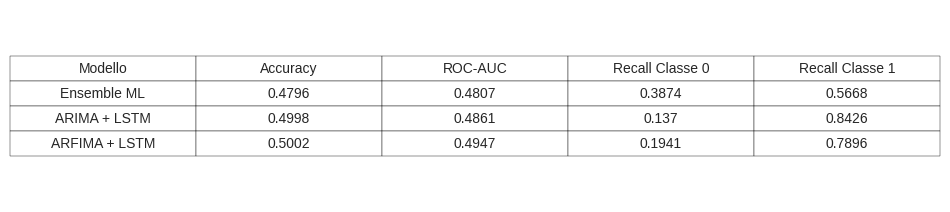

Tabella salvata come: tabella_modelli_daily.png


In [ ]:
# TABELLA COMPARATIVA MODELLI

#------------------------
# Definizione dei dati
data = {
    "Modello": [
        "Ensemble ML",
        "ARIMA + LSTM",
        "ARFIMA + LSTM"
    ],
    "Accuracy": [0.4796, 0.4998, 0.5002],
    "ROC-AUC": [0.4807, 0.4861, 0.4947],
    "Recall Classe 0": [0.3874, 0.1370, 0.1941],
    "Recall Classe 1": [0.5668, 0.8426, 0.7896]
}

df = pd.DataFrame(data)

# Arrotondamento dei numeri a 4 cifre decimali per estetica
df_round = df.copy()
for col in ["Accuracy", "ROC-AUC", "Recall Classe 0", "Recall Classe 1"]:
    df_round[col] = df_round[col].round(4)

#-----------------------
# Creazione della figura
fig, ax = plt.subplots(figsize=(10, 2.5))
ax.axis("off")  # nessun asse, solo la tabella

#------------------------
# Creazione della tabella
table = ax.table(
    cellText=df_round.values,
    colLabels=df_round.columns,
    cellLoc="center",
    loc="center"
)

# Formattazione tabella
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.5)  # (larghezza, altezza delle celle)

#------------------------------
# Salvataggio come immagine PNG
output_path = "tabella_modelli_daily.png"
plt.savefig(output_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Tabella salvata come: {output_path}")

Si prendono i modelli ensemble già addestrati nel walk-forward (LR, RF, XGB);

Costruzione di un 'modello unico' utilizzato solo per la spiegazione (ad esempio il Random Forest o XGBoost perchè migliori per interpretabilità con SHAP TreeExplainer);

Calcolo dei valori SHAP su un campione di test OOS;

Generazione dei grafici:
-SHAP summary plot (densità dei contributi);
-SHAP bar plot (media dei contributi assoluti → importanza globale);
-SHAP dependence plot per feature chiave(lag dei rendimenti,ARIMA_pred,ARFIMA_pred)

Selezione di XGBoost come modello interpretabile con SHAP.

Preparazione dei dati OOS dell’ensemble per l’interpretazione.

Calcolo dei valori SHAP con TreeExplainer.

Generazione dei 3 grafici fondamentali:
-Summary plot; -Bar plot (importanza globale); -Dependence plot per le top 3 feature.

Salvataggio delle immagini in PNG.

Uso di XGBoost come modello interpretabile con SHAP TreeExplainer, perché SHAP con modelli ensemble ibridi non è direttamente definito. Quindi ho deciso di interpretare il modello più performante del paniere.

Shape dei dati SHAP: (2548, 6)

Dimensione valori SHAP: (2548, 6)


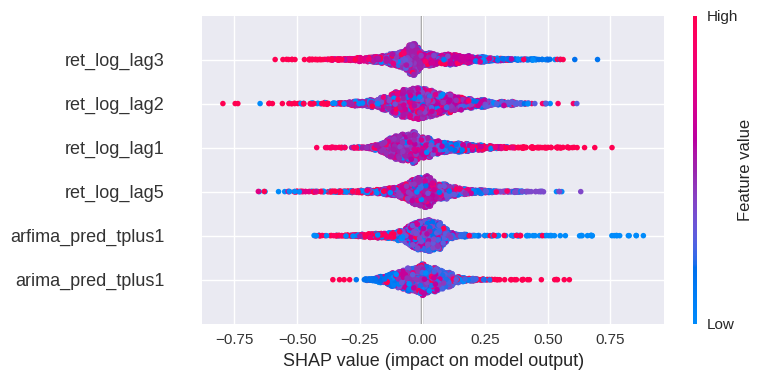

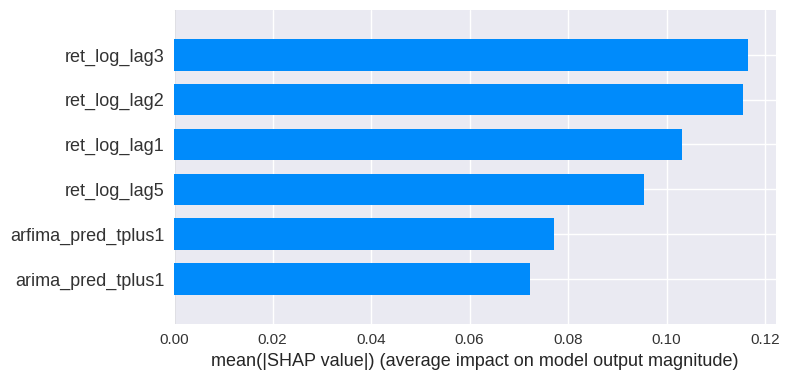


Top 3 feature SHAP: ['ret_log_lag3', 'ret_log_lag2', 'ret_log_lag1']


<Figure size 800x500 with 0 Axes>

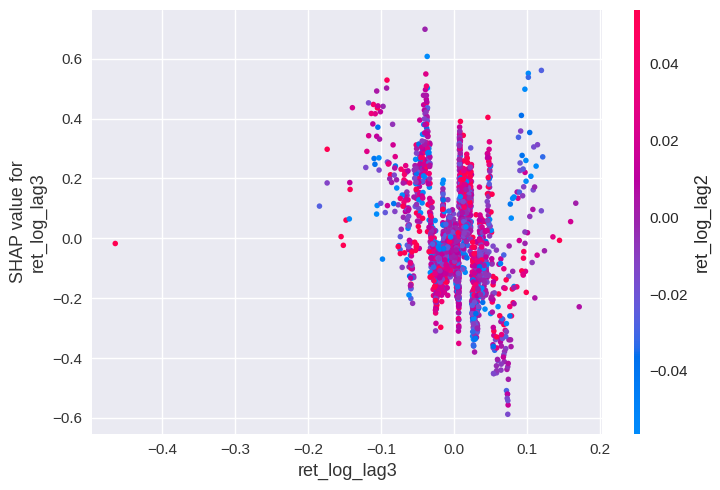

<Figure size 800x500 with 0 Axes>

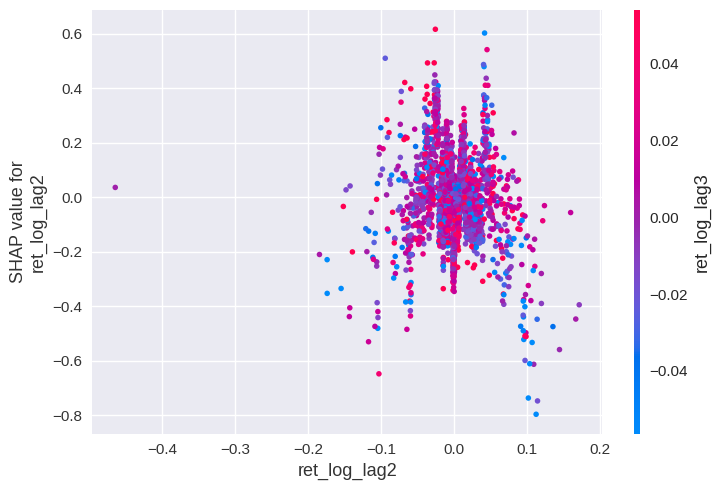

<Figure size 800x500 with 0 Axes>

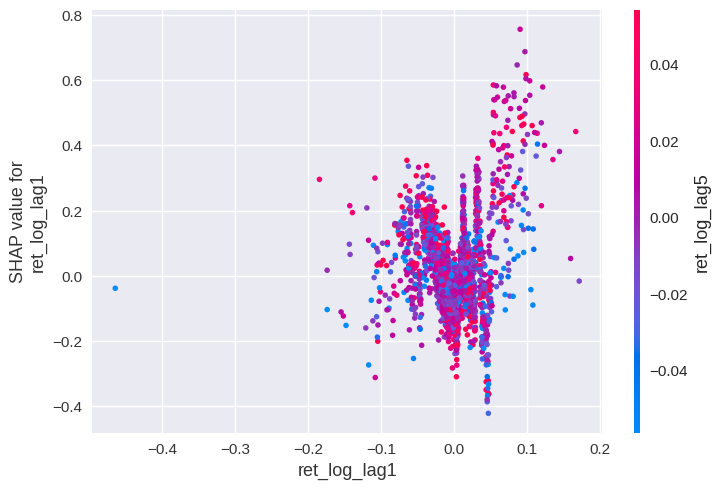

In [ ]:
# INTERPRETABILITÀ CON SHAP


#----------------------------------------
# Selezione del modello da interpretare

# Interpretiamo XGBoost
model_to_explain = xgb_model

#------------------------------
# Preparazione del dataset SHAP

df_shap = df_ml.dropna(subset=feature_cols_hybrid_full).copy()
X_shap = df_shap[feature_cols_hybrid_full].values
features_shap = feature_cols_hybrid_full

print("Shape dei dati SHAP:", X_shap.shape)

#-----------------
# SHAP Explainer

explainer = shap.TreeExplainer(model_to_explain)
shap_values = explainer.shap_values(X_shap)

print("\nDimensione valori SHAP:", np.array(shap_values).shape)

#---------------
# Summary plot

plt.figure(figsize=(10, 5))
shap.summary_plot(
    shap_values,
    X_shap,
    feature_names=features_shap,
    show=False
)
plt.tight_layout()
plt.savefig("shap_summary_daily.png", dpi=300)
plt.show()

# -----------------------------------
# Bar plot dell'importanza globale

plt.figure(figsize=(10, 5))
shap.summary_plot(
    shap_values,
    X_shap,
    feature_names=features_shap,
    plot_type="bar",
    show=False
)
plt.tight_layout()
plt.savefig("shap_bar_daily.png", dpi=300)
plt.show()

#---------------------------------------
# Dependence plot per le top 3 feature

abs_means = np.mean(np.abs(shap_values), axis=0)
top3_idx = np.argsort(abs_means)[-3:][::-1]
top3_features = [features_shap[i] for i in top3_idx]

print("\nTop 3 feature SHAP:", top3_features)

for f in top3_features:
    plt.figure(figsize=(8, 5))
    shap.dependence_plot(
        f,
        shap_values,
        X_shap,
        feature_names=features_shap,
        show=False
    )
    plt.tight_layout()
    plt.savefig(f"shap_dependence_{f}.png", dpi=300)
    plt.show()


Dal dataset df_daily con ret_log si stima un GARCH (1,1) con innovazioni t-Student;

Si producono:
-volatilità condizionata  σt;
-residui standardizzati;
-densità condizionata

Calcolo di VaR, ES e CVaR a 95%;

Unione d tutto in un unico DataFrame df_garch_daily;

Salvataggio grafici.

Numero osservazioni GARCH: 2920

Risultati GARCH(1,1):
                          Zero Mean - GARCH Model Results                           
Dep. Variable:                      ret_log   R-squared:                       0.000
Mean Model:                       Zero Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:               -7478.87
Distribution:      Standardized Student's t   AIC:                           14965.7
Method:                  Maximum Likelihood   BIC:                           14989.7
                                              No. Observations:                 2920
Date:                      Sat, Dec 20 2025   Df Residuals:                     2920
Time:                              03:31:03   Df Model:                            0
                              Volatility Model                             
                 coef    std err          t      P>|t|     95.0% Conf. Int.
----------------------------

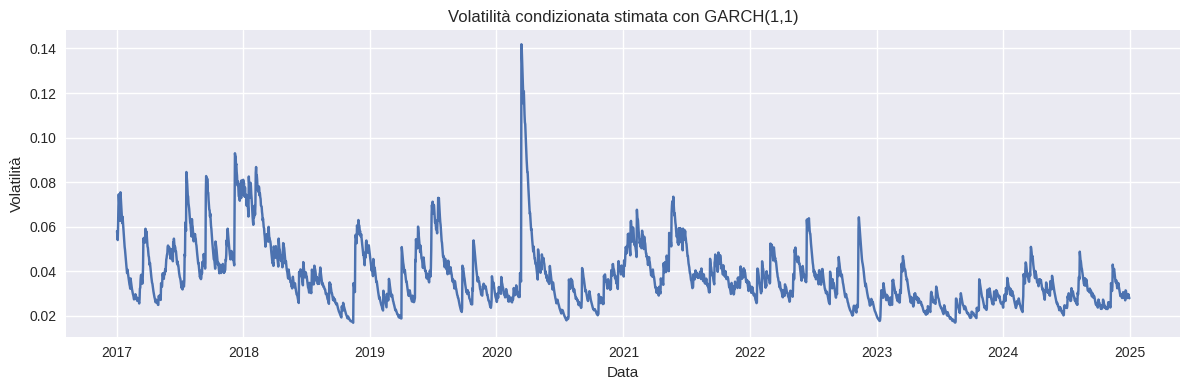

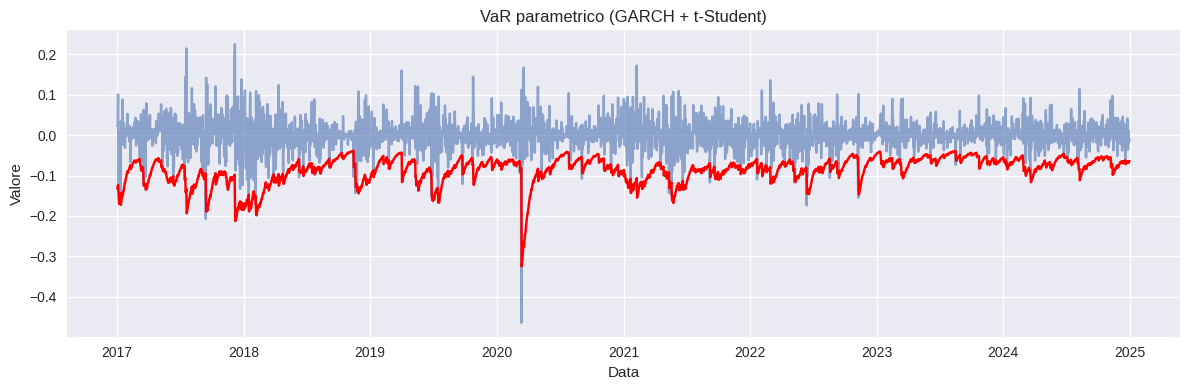

In [ ]:

#GARCH (1,1) + t-Student
# Volatilità condizionata, VaR, ES, CVaR

#------------------------------------------------------------
# Preparazione dei dati, prendo solo la serie dei rendimenti log

df_garch = df_daily.copy()
df_garch = df_garch[["date", "ret_log"]].dropna().reset_index(drop=True)

returns = df_garch["ret_log"] * 100

print("Numero osservazioni GARCH:", len(returns))

#---------------------------------------------------
# Stima modello GARCH (1,1) con innovazioni t-Student

garch_model = arch_model(
    returns,
    vol="Garch",
    p=1,
    q=1,
    dist="t",
    mean="Zero"
)

garch_res = garch_model.fit(disp="off")
print("\nRisultati GARCH(1,1):")
print(garch_res.summary())

#-------------------------------------
# Volatilità condizionata (sigma_t)

df_garch["sigma_t"] = garch_res.conditional_volatility / 100

#-----------------------------------
# 4. Calcolo VaR, ES e CVaR (a 95%)

alpha = 0.95
nu = garch_res.params["nu"]  # gradi di libertà t-Student
sigma = df_garch["sigma_t"].values

# VaR parametrico t-student (1-step ahead)
t_quantile = student_t.ppf(1 - alpha, df=nu)
VaR_95 = sigma * t_quantile

# Expected Shortfall (ES) parametrico
ES_95 = -sigma * (
    (nu + (t_quantile**2)) / ((nu - 1) * (1 - alpha))
) * student_t.pdf(t_quantile, df=nu)

# CVaR identico all’ES in contesto continuo param.
CVaR_95 = ES_95.copy()

df_garch["VaR_95"] = VaR_95
df_garch["ES_95"] = ES_95
df_garch["CVaR_95"] = CVaR_95

print("\nPrime righe df_garch_daily con volatilità e rischi:")
print(df_garch.head())

#-----------------------------------
# Grafico volatilità condizionata

plt.figure(figsize=(12,4))
plt.plot(df_garch["date"], df_garch["sigma_t"], label="Volatilità condizionata (σₜ)")
plt.title("Volatilità condizionata stimata con GARCH(1,1)")
plt.xlabel("Data")
plt.ylabel("Volatilità")
plt.grid(True)
plt.tight_layout()
plt.savefig("garch_volatility_daily.png", dpi=300)
plt.show()

#-------------
# Grafico VaR

plt.figure(figsize=(12,4))
plt.plot(df_garch["date"], df_garch["ret_log"], label="Rendimento log", alpha=0.6)
plt.plot(df_garch["date"], df_garch["VaR_95"], label="VaR 95%", color="red")
plt.title("VaR parametrico (GARCH + t-Student)")
plt.xlabel("Data")
plt.ylabel("Valore")
plt.grid(True)
plt.tight_layout()
plt.savefig("garch_var_daily.png", dpi=300)
plt.show()

# --------------------------
# Salvataggio dataset finale

df_garch_daily = df_garch.copy()


Si prende il dataset ibrido df_ml (ARIMA/ARFIMA + ensemble ML) e il dataset df_garch_daily (volatilità condizionata e VaR/ES/CVaR).

Costruzione del segnale di trading a partire da ens_pred (0/1 → -1/+1).

Uso di y_reg come rendimento del giorno successivo (ret_{t+1}).

Definizione dei costi dinamici proporzionali alla volatilità condizionata GARCH.

Calcolo dei i rendimenti giornalieri della strategia.

Calcolo delle le metriche operative:
-Sharpe ratio annualizzato;
-Sortino ratio annualizzato;
-Max Drawdown;
-Calmar ratio;
-CVaR empirico (95%).

Produzione di due grafici: curva dei capitali (equity curve) e serie del drawdown

Prime righe df_strategy (segnali e target):
        date     y_reg  ens_pred  signal
0 2019-01-07  0.001390         0      -1
1 2019-01-08  0.001103         1       1
2 2019-01-09 -0.092459         1       1
3 2019-01-10  0.002292         0      -1
4 2019-01-11 -0.007094         0      -1

Dopo merge con volatilità (sigma_t):
        date     y_reg  signal   sigma_t
0 2019-01-07  0.001390      -1  0.042521
1 2019-01-08  0.001103       1  0.041008
2 2019-01-09 -0.092459       1  0.039401
3 2019-01-10  0.002292      -1  0.037875
4 2019-01-11 -0.007094      -1  0.045579

Prime righe con rendimenti della strategia:
        date  ret_asset_next  signal    cost_t  ret_strat
0 2019-01-07        0.001390      -1  0.004452  -0.005842
1 2019-01-08        0.001103       1  0.004301  -0.003198
2 2019-01-09       -0.092459       1  0.004140  -0.096599
3 2019-01-10        0.002292      -1  0.003988  -0.006279
4 2019-01-11       -0.007094      -1  0.004758   0.002336

Metriche di rischio strategia EN

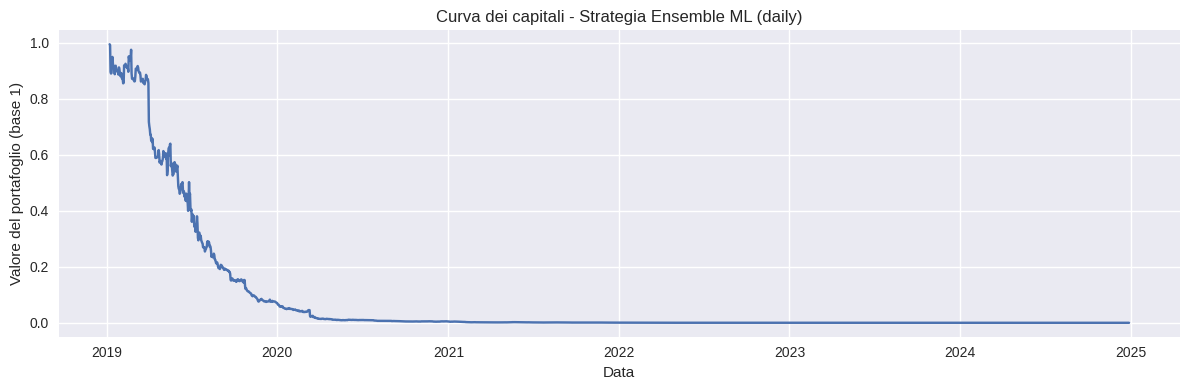

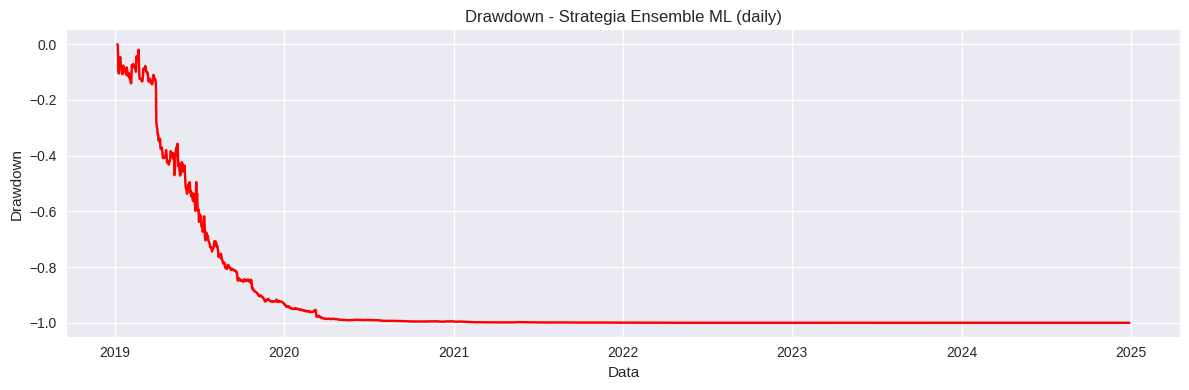


df_strategy pronto con rendimenti, equity e drawdown.


In [ ]:
# METRICHE DI RISCHIO STRATEGIA ENSEMBLE ML


#------------------------------------------------------------
# Preparazione del dataset strategia: segnali + rendimenti

df_strategy = df_ml.copy()

# Mantengo solo le osservazioni con previsione ensemble e target disponibili
df_strategy = df_strategy.dropna(subset=["ens_pred", "y_reg"]).reset_index(drop=True)

# Conversione ens_pred in interi (0/1)
df_strategy["ens_pred"] = df_strategy["ens_pred"].astype(int)

# Costruzione del segnale: 0 -> -1 (short), 1 -> +1 (long)
df_strategy["signal"] = 2 * df_strategy["ens_pred"] - 1

print("Prime righe df_strategy (segnali e target):")
print(df_strategy[["date", "y_reg", "ens_pred", "signal"]].head())

#------------------------------------------------------------
# Merge con la volatilità condizionata GARCH

df_garch_daily_merge = df_garch_daily[["date", "sigma_t"]].copy()

df_strategy = df_strategy.merge(
    df_garch_daily_merge,
    on="date",
    how="inner"
)

print("\nDopo merge con volatilità (sigma_t):")
print(df_strategy[["date", "y_reg", "signal", "sigma_t"]].head())

#-------------------------------
# Definizione dei costi dinamici

# Parametri dei costi
C0 = 0.0002   # componente fissa (es. 2 bps per operazione)
C1 = 0.10     # componente proporzionale alla volatilità condizionata

# Costi giornalieri
df_strategy["cost_t"] = C0 + C1 * df_strategy["sigma_t"]

#-----------------------------------------
# Rendimenti giornalieri della strategia

# Rendimento dell'asset il giorno successivo
df_strategy["ret_asset_next"] = df_strategy["y_reg"]

# Rendimento della strategia:
# r_strat_t = signal_t * r_{t+1} - cost_t
df_strategy["ret_strat"] = df_strategy["signal"] * df_strategy["ret_asset_next"] - df_strategy["cost_t"]

print("\nPrime righe con rendimenti della strategia:")
print(df_strategy[["date", "ret_asset_next", "signal", "cost_t", "ret_strat"]].head())

#-------------------------------------
# Calcolo delle metriche di rischio

ret_strat = df_strategy["ret_strat"].dropna().values

# Parametro numero di giorni di trading per anno
TRADING_DAYS = 252

# Media e deviazione standard giornaliera
mu_daily = np.mean(ret_strat)
sigma_daily = np.std(ret_strat, ddof=1)

# Rendimento e volatilità annualizzati
mu_annual = mu_daily * TRADING_DAYS
sigma_annual = sigma_daily * np.sqrt(TRADING_DAYS)

# Sharpe ratio (senza risk-free esplicito)
sharpe_ratio = mu_annual / sigma_annual if sigma_annual > 0 else np.nan

# Sortino ratio, uso solo la deviazione standard delle perdite
ret_strat_downside = ret_strat[ret_strat < 0]
sigma_down_daily = np.std(ret_strat_downside, ddof=1) if len(ret_strat_downside) > 0 else np.nan
sigma_down_annual = sigma_down_daily * np.sqrt(TRADING_DAYS) if not np.isnan(sigma_down_daily) else np.nan

sortino_ratio = mu_annual / sigma_down_annual if (sigma_down_annual is not None and sigma_down_annual > 0) else np.nan

# Equity curve
equity_curve = (1 + df_strategy["ret_strat"].fillna(0)).cumprod()
df_strategy["equity"] = equity_curve

# Max Drawdown
cummax_equity = df_strategy["equity"].cummax()
drawdown = df_strategy["equity"] / cummax_equity - 1.0
df_strategy["drawdown"] = drawdown

max_drawdown = drawdown.min()  # valore negativo

# Calmar ratio, rapporto tra rendimento annualizzato e drawdown massimo (in valore assoluto)
calmar_ratio = mu_annual / abs(max_drawdown) if max_drawdown < 0 else np.nan

# CVaR empirico (95%)
alpha = 0.95
var_95_emp = np.quantile(ret_strat, 1 - alpha)
cvar_95_emp = ret_strat[ret_strat <= var_95_emp].mean()

#------------------------------------------------------------
# Stampa delle metriche di rischio

print("\nMetriche di rischio strategia ENSEMBLE ML (daily):")
print(f"Rendimento medio giornaliero: {mu_daily:.6f}")
print(f"Rendimento medio annualizzato: {mu_annual:.4f}")
print(f"Volatilità annualizzata: {sigma_annual:.4f}")
print(f"Sharpe ratio: {sharpe_ratio:.4f}")
print(f"Sortino ratio: {sortino_ratio:.4f}")
print(f"Max Drawdown: {max_drawdown:.4f}")
print(f"Calmar ratio: {calmar_ratio:.4f}")
print(f"VaR empirico 95%: {var_95_emp:.4f}")
print(f"CVaR empirico 95%: {cvar_95_emp:.4f}")

#----------------------------------
# Grafici: Equity curve e Drawdown

plt.figure(figsize=(12,4))
plt.plot(df_strategy["date"], df_strategy["equity"], label="Equity curve strategia Ensemble ML")
plt.xlabel("Data")
plt.ylabel("Valore del portafoglio (base 1)")
plt.title("Curva dei capitali - Strategia Ensemble ML (daily)")
plt.grid(True)
plt.tight_layout()
plt.savefig("equity_ensemble_daily.png", dpi=300)
plt.show()

plt.figure(figsize=(12,4))
plt.plot(df_strategy["date"], df_strategy["drawdown"], label="Drawdown", color="red")
plt.xlabel("Data")
plt.ylabel("Drawdown")
plt.title("Drawdown - Strategia Ensemble ML (daily)")
plt.grid(True)
plt.tight_layout()
plt.savefig("drawdown_ensemble_daily.png", dpi=300)
plt.show()

print("\ndf_strategy pronto con rendimenti, equity e drawdown.")
